# Estimação pontual

<hr>

A estimação pontual consiste no uso de uma amostra aleatória (uma coleção de variáveis observadas de forma independente) para obter um único valor numérico, chamado de estimador, que represente um parâmetro desconhecido da população
. Enquanto o parâmetro é uma característica fixa da população, o estimador é uma função matemática aplicada aos dados da amostra para inferir esse valor

#### Funcionalidade na Estatística

A principal função da estimação pontual é permitir a inferência estatística, ou seja, tirar conclusões sobre uma população inteira baseando-se apenas em uma parte dela (a amostra)

O método mais relevante apresentado nas fontes é o *Estimador de Máxima Verossimilhança (EMV)*

Sua lógica funciona da seguinte forma:
- **Função de Verossimilhança**: Calcula-se a probabilidade (ou densidade) conjunta de observar os dados da amostra para diferentes valores do parâmetro

- **Maximização**: O estimador ideal é aquele que maximiza essa probabilidade, ou seja, o valor do parâmetro que torna os dados observados "mais prováveis"

- **Propriedades de Qualidade**: Para ser considerado bom, um estimador deve idealmente ser não viesado (sua média esperada deve coincidir com o parâmetro real), consistente (tornar-se mais exato conforme a amostra aumenta) e eficiente (apresentar a menor variância possível)

#### Conexão com Data Science e Machine Learning

A conexão técnica entre os conceitos da fonte e as áreas de Data Science e Machine Learning é fundamental, pois o "aprendizado" de um modelo é, na essência, um problema de estimação:
Ajuste de Modelos: O material demonstra como encontrar os parâmetros ideais para distribuições como a Gaussiana (Normal), Binomial ou Exponencial a partir de dados

Em Data Science, isso é usado para descrever o comportamento de variáveis e prever eventos futuros

- **Treinamento de Algoritmos**: (Nota: Informação externa aos slides para contextualização) Muitos algoritmos de Machine Learning, como a Regressão Logística, utilizam o princípio da Máxima Verossimilhança citado na fonte para encontrar os pesos (parâmetros) que melhor ajustam o modelo aos dados de treinamento

- **Inferência de Padrões**: A capacidade de um modelo de "generalizar" para novos dados depende das propriedades de consistência e ausência de viés discutidas nos slides, garantindo que o modelo aprenda a estrutura real dos dados e não apenas ruídos da amostra

---

#### Conceitos Fundamentais

A estimação busca inferir características de uma população a partir de uma amostra observada.

- **Parâmetro (θ):** medida que descreve uma característica da população.  
- **Amostra Aleatória:** coleção de variáveis aleatórias  
  \( X_1, X_2, \dots, X_n \) independentes e identicamente distribuídas (i.i.d.).  
- **Estatística:** qualquer função baseada nos elementos da amostra aleatória.  
- **Estimador (θ̂):** estatística usada para estimar um parâmetro populacional.

Uma amostra aleatória é uma coleção de variáveis aleatória $X_1,X_2,\ldots, X_n$ independentes e identicamente distribuídas

In [1]:
import numpy as np
np.random.seed(100)
mu = 10 # média da população
sigma = 2 # desvio padrão da população
n = 10 # tamanho da amostra
x = np.random.normal(mu, sigma, n)
print('Amostra aleatória:')
print(x)

Amostra aleatória:
[ 6.50046905 10.68536081 12.30607161  9.49512793 11.96264157 11.02843768
 10.44235934  7.85991334  9.62100834 10.51000289]


Vamos gerar outra amostra, que representa o número de horas que estudantes gastam na internet por semana.

In [2]:
import numpy as np
np.random.seed(100)
mu = 15
sigma = 2
n = 10
s = np.random.normal(mu, sigma, n)
print('Amostra:')
for i in s:
    print(int(10*i)/10,end = ';')
print("\nMédia da amostra:", np.mean(s))

Amostra:
11.5;15.6;17.3;14.4;16.9;16.0;15.4;12.8;14.6;15.5;
Média da amostra: 15.041139255352794


In [3]:
s = np.random.normal(mu, sigma, n)
print("Amostra:", s)
print('Média amostral:', np.mean(s))
print('Média populacional:', mu)

Amostra: [14.08394603 15.87032698 13.8328099  16.63369414 16.34544161 14.79117771
 13.93743925 17.05946537 14.12372875 12.76336351]
Média amostral: 14.944139325124798
Média populacional: 15


---

### Distribuição normal

Vamos supor que temos uma população que segue o modelo normal,  de modo que $X_1,X_2,\ldots, X_n \sim \mathcal{N}(\mu=5,\sigma = 0.5)$. Observamos que quando aumentamos o tamanho da amostra, o valor da média amostral, que é o estimador da média para a distribuição gaussiana, converge para a média populacional $\mu = 5$. Esse resultado concorda com o fato do estimador de máxima verossimilhança ser assintoticamente não viesado.

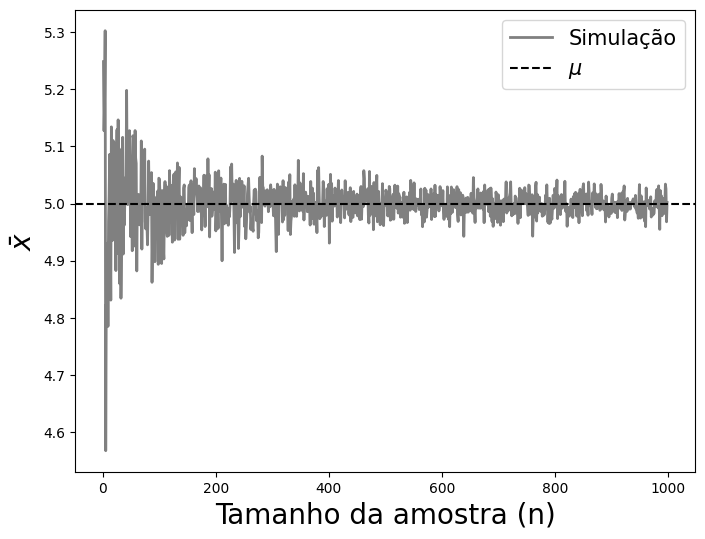

In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

mu = 5 # média populacional
sigma = 0.5 # desvio padrão populacional
xhat = []
# tamanhos das amostras de 1 até 999
ns = np.arange(1,1000,1)
for n in ns:
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # armazena média amostral
    xhat.append(np.mean(x))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, xhat, linestyle='-', color="gray",
         linewidth=2,label = 'Simulação')
plt.axhline(y=mu, color='black', linestyle='--',
            label = r'$\mu$')
plt.ylabel(r'$\bar{x}$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

Vamos verificar essa convergência para o caso da variância.

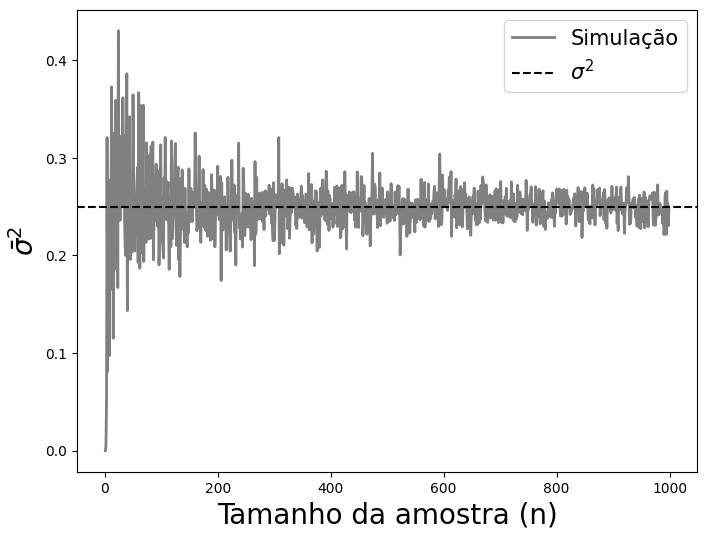

In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(101)

# função para calcular a variância amostral
def variancia(x):
    m = np.mean(x)
    sigma2 = 0
    for xi in x:
        sigma2 = sigma2 + (xi-m)**2
    sigma2 = sigma2/n
    return sigma2

mu = 5 # média populacional
sigma = 0.5 # desvio padrão populacional
s_hat = []
# tamanhos das amostras de 1 até 999
ns = np.arange(1,1000)
for n in ns:
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n)
    # calcula o estimador da variância
    s_hat.append(variancia(x))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(ns, s_hat, linestyle='-', color="gray",
         linewidth=2,label = 'Simulação')
plt.axhline(y=sigma**2, color='black', linestyle='--',
            label = r'$\sigma^2$')
plt.ylabel(r'$\bar{\sigma}^2$', fontsize=20)
plt.xlabel("Tamanho da amostra (n)", fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

---
### Distribuição Exponencial

Seja uma variável aleatória $X$ com distribuição exponencial, isto é,
$$
f(x))=
\begin{cases}
\theta e^{-\theta x}, \quad x \geq 0,\\
0, \quad x < 0. \\
\end{cases}
$$
Vimos que o estimador de máxima verossimilhança é dado por:
$$
\hat{\theta} = \frac{n}{\sum_{i=1}^n x_i}.
$$
Verifique esse resultado através de simulação.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

theta = 5 # parâmetro
n = 100
X = np.random.exponential(1/theta, n)
theta_hat = n/np.sum(X)
print('Valor estimado:', theta_hat)

Valor estimado: 5.468674605892398


---
### Distribuição binomial:

In [9]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

theta = 0.2 # probabilidade de sucesso
m = 10 # número de lançamentos
n = 100 # número de amostras
# gera os dados
X = np.random.binomial(m, theta,n)
# calcula o estimador
theta_hat = np.sum(X)/(n*m)
print('Valor estimado:', theta_hat)

Valor estimado: 0.188


Podemos variar o tamanho da amostra.

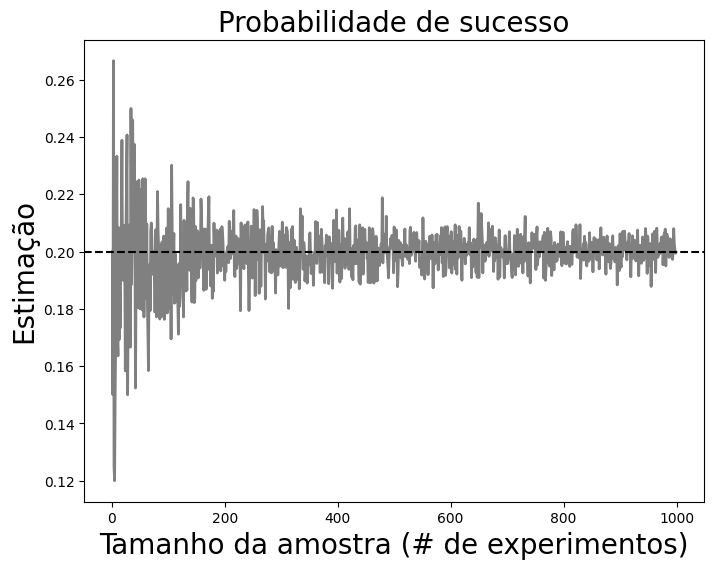

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# função para calcular o estimador
def estimador_binomial(X,m):
    xs = np.sum(X)/(len(X)*m)
    return xs

p = 0.2 # probabilidade de sucesso
m = 10 # número de lançamentos
vxs = []
vn = []
# varia o tamanho da amostra
for n in range(1,1000):
    # gera os dados
    X = np.random.binomial(m, p,n)
    # calcula o estimador
    xs = estimador_binomial(X,m)
    vxs.append(xs)
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.title('Probabilidade de sucesso', fontsize=20)
plt.plot(vn, vxs, linestyle='-', color="gray", linewidth=2,label = 'Valor simulado')
plt.axhline(y=p, color='k', linestyle='--', label = 'Valor teorico')
plt.ylabel("Estimação", fontsize=20)
plt.xlabel("Tamanho da amostra (# de experimentos)", fontsize=20)
plt.show(True)

---
### O EMV é assintoticamente normal:

O EMV é o valor de θ que maximiza a verossimilhança.

*Passo a passo:*

1. Definir a função de verossimilhança \( L(\theta) \)  
2. Calcular a log-verossimilhança \( \ell(\theta) \)  
3. Derivar em relação a θ  
4. Igualar a zero e resolver para encontrar \( \hat{\theta} \)

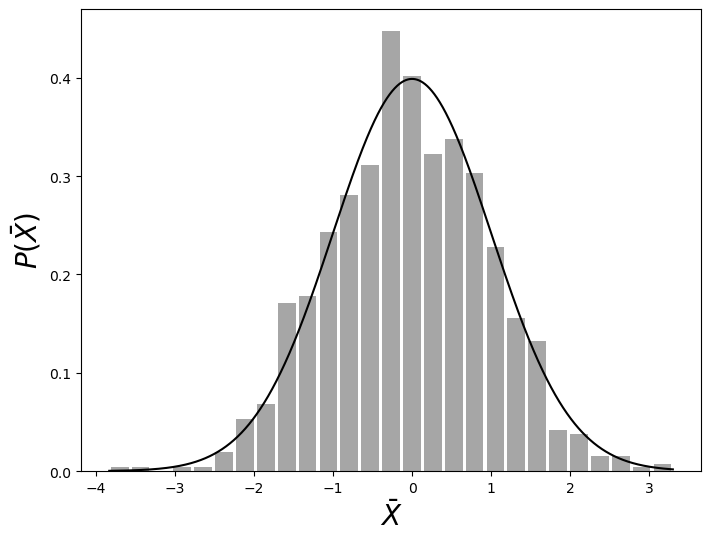

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(42)

# parâmetros da distribuição normal
mu = 5; sigma = 0.5
n = 1000 # tamanho da amostra
x_hat = [] # armazena a média amostral
# gera 1000 simulações
for s in np.arange(1,1000,1):
    # gera uma amostra de tamanho n
    sample = np.random.normal(mu, sigma, n)
    # guarda a média amostral
    x_hat.append(np.mean(sample))
# calcula Q = (theta_hat - theta)/sqrt(V(theta))
Q = (np.array(x_hat) - mu)/np.sqrt(np.var(x_hat))
# mostra os resultados
plt.figure(figsize=(8,6))
plt.hist(x=Q, bins='auto', color='gray',
         alpha=0.7, rwidth=0.85, density=True)
plt.xlabel(r'$\bar{X}$', fontsize=20)
plt.ylabel(r'$P(\bar{X})$', fontsize=20)
# mostra a distribuição normal padronizada
xmin, xmax = min(Q), max(Q)
x = np.arange(xmin, xmax, 0.001)
y = stats.norm.pdf(x,0,1)
plt.plot(x, y, label="Norm", color='black')
plt.savefig('MLnormal.svg')
plt.show(True)

---
#### Conexão com Machine Learning

In [1]:
import numpy as np

# População real
populacao = np.random.normal(loc=100, scale=15, size=100000)

# Amostra retirada da população
amostra = np.random.choice(populacao, size=50, replace=False)

# Parâmetro real da população
media_populacional = populacao.mean()

# Estimação pontual
media_amostral = amostra.mean()

print("Média real da população:", media_populacional)
print("Estimativa pela amostra:", media_amostral)

Média real da população: 99.92196038319967
Estimativa pela amostra: 98.8839178638994


A lógica é:

In [ ]:
media_amostral = amostra.mean()

Aqui, a média amostral é o estimador pontual da média populacional.

Ou seja:

- Parâmetro populacional: μ
- Estimador: X̄
- Estimativa pontual: valor calculado com a amostra

Exemplo conceitual:

- Média real da população: 100

- Média da amostra: 98.7

Você não conhece a média real da população, então usa 98.7 como uma estimativa.

Em Machine Learning acontece algo parecido:

In [ ]:
from sklearn.linear_model import LinearRegression

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()
model.fit(X, y)

print("Coeficiente estimado:", model.coef_)
print("Intercepto estimado:", model.intercept_)

Nesse caso, o modelo estima os parâmetros da reta:

- y = β0 + β1x

O model.coef_ é a estimativa de β1.

O model.intercept_ é a estimativa de β0.

Então,

Estatística clássica:
usa amostra para estimar média, variância, proporção etc.

Machine Learning:
usa dados para estimar parâmetros de modelos.

- Treinar um modelo = encontrar boas estimativas para seus parâmetros.